# FDCA Part I — Walkthrough paso a paso

Este notebook desglosa **`part1.py`** del pipeline GERIS-PFC, ejecutando cada etapa de forma aislada y mostrando qué produce.

La estructura sigue las secciones ATBD 3.4.2.1 → 3.4.2.13:

| Sección | Qué hace |
|---------|----------|
| 3.4.2.1 | Albedo y brillo visible |
| 3.4.2.2 | Banda híbrida FPT + producto Reflectividad |
| 3.4.2.3 | Tests de nube y geometría |
| 3.4.2.4 | Test along-scan |
| 3.4.2.5 | Background estadístico |
| 3.4.2.6 | Umbrales contextuales |
| 3.4.2.7 | Identificación inicial de píxeles de fuego |
| 3.4.2.8 | Correcciones TPW + emisividad + solar |
| 3.4.2.9 | Tests post-corrección |
| 3.4.2.10 | Dozier sub-pixel + área |
| 3.4.2.11 | Last-chance fire test |
| 3.4.2.12 | FRP |
| 3.4.2.13 | Registro del candidato |



## 0. Setup: cargar repo del proyecto y archivos a utilizar


In [ ]:
import os
import sys
import subprocess
from pathlib import Path

# Detectar si estamos en Google Colab
try:
    from google.colab import userdata
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

BRANCH = "testing-fdca-real"

if IN_COLAB:
    print("Ejecutando en Google Colab")

    GH_TOKEN = userdata.get("GITHUB_TOKEN")
    REPO_URL = f"https://{GH_TOKEN}@github.com/Vale23-23/GERIS-PFC.git"
    CLONE_DIR = "/content/GERIS-PFC"

    if not os.path.exists(CLONE_DIR):
        result = subprocess.run(
            [
                "git", "clone",
                "--branch", BRANCH,
                "--depth", "1",
                REPO_URL,
                CLONE_DIR
            ],
            capture_output=True,
            text=True
        )

        if result.returncode != 0:
            raise RuntimeError(result.stderr)

        print("Repo clonado OK")

    else:
        pull = subprocess.run(
            ["git", "-C", CLONE_DIR, "pull"],
            capture_output=True,
            text=True
        )
        print("Pull OK")

    PROJECT_ROOT = Path(CLONE_DIR) / "implementacion"

else:
    print("Ejecutando localmente (VS Code u otro IDE)")

    cwd = Path.cwd()
    if (cwd / "implementacion" / "fdca").exists():
        PROJECT_ROOT = cwd / "implementacion"
    elif (cwd / "fdca").exists():
        PROJECT_ROOT = cwd
    else:
        PROJECT_ROOT = cwd

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

sys.path.insert(0, str(PROJECT_ROOT))

Ejecutando localmente (VS Code u otro IDE)
PROJECT_ROOT = /Users/valentinachagas/Documents/GitHub/GERIS-PFC/implementacion


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [5]:
# ── Celda 2: bajar datos desde Hugging Face ───────────────────────────────
import os

try:
    from google.colab import userdata
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    HF_TOKEN = userdata.get("HF_TOKEN")
    DATA_ROOT = "/content/data"
else:
    from dotenv import load_dotenv

    env_candidates = [Path.cwd() / ".env", Path.cwd().parent / ".env"]
    for env_path in env_candidates:
        if env_path.exists():
            load_dotenv(env_path)
            break

    HF_TOKEN = os.getenv("HF_TOKEN")
    DATA_ROOT = Path.cwd() / "data"

from huggingface_hub import snapshot_download

HF_REPO_ID = "valentina2323/GERIS-Goes19-uruguay-fires"
TIMESTAMP = "20250926_1900"
LOCAL_DATA = os.path.join(DATA_ROOT, TIMESTAMP)

os.makedirs(LOCAL_DATA, exist_ok=True)

snapshot_download(
    repo_id=HF_REPO_ID,
    repo_type="dataset",
    token=HF_TOKEN,
    allow_patterns=[
        f"uruguay/*/{TIMESTAMP}.npy",
        "uruguay/**/*.json",
    ],
    local_dir=str(DATA_ROOT),
)

print(f"Datos en: {LOCAL_DATA}")

/Users/valentinachagas/Documents/GitHub/GERIS-PFC/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching ... files: 18it [00:00, 9064.41it/s]

Datos en: /Users/valentinachagas/Documents/GitHub/GERIS-PFC/implementacion/data/20250926_1900


In [6]:
from pathlib import Path

print(list(Path(DATA_ROOT).glob("*")))

[PosixPath('/Users/valentinachagas/Documents/GitHub/GERIS-PFC/implementacion/data/uruguay'), PosixPath('/Users/valentinachagas/Documents/GitHub/GERIS-PFC/implementacion/data/20250926_1900'), PosixPath('/Users/valentinachagas/Documents/GitHub/GERIS-PFC/implementacion/data/.cache')]


## 1. Cargar datos de entrada (`FDCAInput`)

Usamos la misma escena de prueba del README: timestamp `20250926_1900`.

In [7]:
# ── Celda 3: imports y carga del input ───────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pathlib import Path
import json, warnings

# Módulos del proyecto
from fdca.fdca_adapter import load_fdca_input
from fdca.constants import FireMask, FailChar, BKG_MAX_ITER
from fdca.planck import planck_rad, planck_temp
from fdca.background import compute_background
from fdca.dozier import compute_dozier, compute_frp, compute_pixel_area
from fdca.part1 import (
    FireCandidate, _contextual_thresholds,
    _tpw_lut_indices, _solar_correction,
    run_part1,
)
from fdca.constants import *

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [8]:
import sys
import numpy as np
sys.path.insert(0, str(PROJECT_ROOT))

from fdca.fdca_adapter import load_fdca_input

CONFIG_PATH = str(PROJECT_ROOT / "fdca" / "config.yaml")
DATASET_ROOT = str(DATA_ROOT)   # si la celda anterior definió DATA_ROOT

inp = load_fdca_input(
    timestamp=TIMESTAMP,
    region="uruguay",
    config_path=CONFIG_PATH,
    dataset_root=DATASET_ROOT,
    verbose=True
)

print(f"Grilla: {inp.bt7.shape}  |  BT7 [{np.nanmin(inp.bt7):.1f}, {np.nanmax(inp.bt7):.1f}] K")



  ABI-L1b-Rad-B07       : shape=(224, 303)  range=[0.58, 25.59]
  ABI-L1b-Rad-B14       : shape=(224, 303)  range=[75.79, 196.25]
  ABI-L1b-Rad-B13       : shape=(224, 303)  range=[66.67, 177.84]
  ABI-L1b-Rad-B15       : shape=(224, 303)  range=[75.24, 181.48]
  ABI-L1b-Rad-B02       : shape=(893, 1212)  range=[12.06, 344.00]

  SZA range [°]         : 48.0 – 55.9
  LZA range [°]         : 31.3 – 40.1
  Píxeles diurnos       : 100%

  BT7 range [K]         : 288.9 – 410.9
  BT14 range [K]        : 271.9 – 339.2
  refl2 range           : 0.051 – 0.352
  TPW range [mm]        : 25.0 – 35.0  (estimación climatológica)

  ✓ FDCAInput construido — shape (224, 303)
Grilla: (224, 303)  |  BT7 [288.9, 410.9] K


In [9]:
import pandas as pd

# Ver los atributos principales del objeto
fields = {
    "campo": [],
    "tipo": [],
    "shape": [],
}

for name in dir(inp):
    if name.startswith("_"):
        continue
    value = getattr(inp, name)
    if hasattr(value, "shape"):
        fields["campo"].append(name)
        fields["tipo"].append(type(value).__name__)
        fields["shape"].append(value.shape)
    elif hasattr(value, "__len__") and not isinstance(value, (str, bytes)):
        try:
            fields["campo"].append(name)
            fields["tipo"].append(type(value).__name__)
            fields["shape"].append(len(value))
        except Exception:
            pass

pd.DataFrame(fields).head(50)

,campo,tipo,shape
0,azimuth,ndarray,"(224, 303)"
1,bt13,ndarray,"(224, 303)"
2,bt14,ndarray,"(224, 303)"
3,bt15,ndarray,"(224, 303)"
4,bt7,ndarray,"(224, 303)"
5,coeffs13,dict,4
6,coeffs14,dict,4
7,coeffs15,dict,4
8,coeffs7,dict,4
9,desert_mask,ndarray,"(224, 303)"


In [10]:
# Ejemplo: ver un resumen de una variable
pd.Series(inp.sza[0, :10]).to_frame(name="BT7 primer fila")

,BT7 primer fila
0,48.010540
1,48.028419
2,48.046314
3,48.064198
4,48.082088
5,48.099991
6,48.117889
7,48.135788
8,48.153698
9,48.171619


---
## Paso 1 — ATBD 3.4.2.1: Albedo y brillo visible

El albedo normalizado por SZA se calcula como:
$$\text{albedo}_{ij} = \frac{\text{refl2}_{ij}}{\cos(\text{SZA}_{ij})}$$

Solo aplica de día (`SZA ≤ MAX_SZA_DAYLIGHT = 85°`).
Esto corrige la reflectancia cruda por el ángulo de iluminación solar: a mayor SZA, el sol ilumina más oblicuamente y la misma superficie parece más brillante en reflectancia cruda. Al dividir por cos(SZA) se obtiene una medida más "física" de la reflectividad real.

Se maneja en una escala adimensional que va de 0.0 a 1.5 (donde valores mayores a 1.0 surgen técnicamente por la geometría de la reflexión y el ruido).  


In [11]:
from fdca.part1 import calculate_albedo

L, W = inp.bt7.shape

albedo, vis_brightness, is_day, sza_cos = calculate_albedo(L, W, inp.sza, inp.refl2)

print(f'Píxeles diurnos : {is_day.sum():,} / {L*W:,} ({100*is_day.mean():.1f}%)')
print(f'Albedo válido   : {np.isfinite(albedo).sum():,} píxeles')
print(f'Albedo rango    : [{np.nanmin(albedo):.4f}, {np.nanmax(albedo):.4f}]')

Píxeles diurnos : 67,872 / 67,872 (100.0%)
Albedo válido   : 67,872 píxeles
Albedo rango    : [0.0878, 0.5563]


In [12]:
albedo.mean()

0.16789068

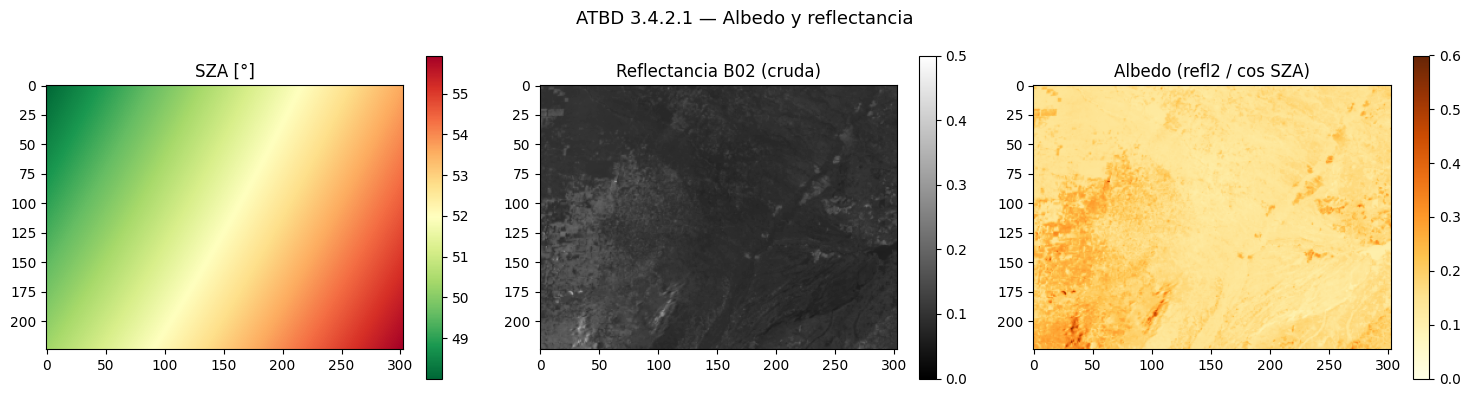

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(inp.sza, cmap='RdYlGn_r', origin='upper')
plt.colorbar(im0, ax=axes[0])
axes[0].set_title('SZA [°]')

if inp.refl2 is not None:
    im1 = axes[1].imshow(inp.refl2, cmap='gray', origin='upper', vmin=0, vmax=0.5)
    plt.colorbar(im1, ax=axes[1])
    axes[1].set_title('Reflectancia B02 (cruda)')
else:
    axes[1].text(0.5, 0.5, 'B02 no disponible', ha='center', va='center', transform=axes[1].transAxes)

im2 = axes[2].imshow(albedo, cmap='YlOrBr', origin='upper', vmin=0, vmax=0.6)
plt.colorbar(im2, ax=axes[2])
axes[2].set_title('Albedo (refl2 / cos SZA)')

plt.suptitle('ATBD 3.4.2.1 — Albedo y reflectancia', fontsize=13)
plt.tight_layout()
plt.show()

El sol está más alto en el cielo hacia la izquierda de la imagen (oeste) y más bajo (más inclinado, proyectando más sombras) hacia la derecha (este). Esta inclinación causa que, a igual tipo de suelo, la derecha de la imagen reciba naturalmente menos iluminación solar directa que la izquierda.
El albedo es el factor de reflectancia corregido y normalizado que utiliza el FDCA para sus árboles de decisión diurnos. Al dividir la reflectancia cruda por el coseno del ángulo solar (SZA) de cada píxel, eliminás el efecto de iluminación oblicua causado por la curvatura de la Tierra y la hora del día. Los valores dominantes están en el rango de 0.1 a 0.25 (tonos amarillos y crema suaves), que es el rango exacto de validación física para pastizales, campos de cultivo y montes limpios en el Cono Sur. Hacia el extremo inferior izquierdo (suroeste), se aprecian algunas estructuras con un albedo levemente más alto (tonos naranja/marrón de 0.25 a 0.35) que podrían ser suelos más descubiertos, texturas de biomas mixtos o nubes muy delgadas/humo que empiezan a dispersar luz visible sin llegar al umbral crítico de nube opaca (>0.38).  

---
## Paso 2 — ATBD 3.4.2.2: Banda híbrida FPT + producto Reflectividad

Si la temperatura del plano focal (`FPT > FPT_THRESHOLD`), el detector de B07 está tan caliente que contamina las mediciones, y en ese caso se substituye B14 por B13, donde reduce la diferencia con B07. Luego se calcula el **producto Reflectividad** para todos los píxeles:

$$\text{Refl}_{ij} = \text{rad7}_{ij} - B_{\text{Planck}}(7,\, \text{BT14}_{ij})$$

In [14]:
# Leer FPT del input 
FPT = inp.FPT
AFFECTED_PIXELS = FPT > FPT_THRESHOLD # Si FPT supera el umbral, entonces hay pixeles afectados

print(f'FPT= {FPT:.2f}   |   FPT_THRESHOLD = {FPT_THRESHOLD} K   |   posible uso híbrido = {AFFECTED_PIXELS}')

if AFFECTED_PIXELS == True :
    use_hybrid = True
else:
    use_hybrid = False #es como overkill, podriamos ver que sea con el 10% afectados

if use_hybrid and inp.bt13 is not None:
    rad13_in_ch7 = planck_rad(7, inp.bt13)
    rad14_in_ch7 = planck_rad(7, inp.bt14)
    refl_7_14 = inp.rad7 - rad14_in_ch7
    refl_7_13 = inp.rad7 - rad13_in_ch7

    use_ch13  = np.abs(refl_7_13) < np.abs(refl_7_14)
    bt14_eff  = np.where(use_ch13, inp.bt13, inp.bt14)
    rad14_eff = np.where(use_ch13, inp.rad13, inp.rad14)
    print(f'Píxeles donde B13 reemplaza B14: {use_ch13.sum():,}')
else:
    bt14_eff  = inp.bt14
    rad14_eff = inp.rad14
    print('Usando B14 estándar (sin banda híbrida)')

# Producto Reflectividad
rad14_in_7 = planck_rad(7, bt14_eff)
refl       = inp.rad7 - rad14_in_7
bad_rad    = (inp.rad7 < 0) | (rad14_eff < 0)
refl       = np.where(bad_rad, -9999.0, refl)

print(bad_rad.sum())
print(refl.min())


FPT= 0.00   |   FPT_THRESHOLD = 90.0 K   |   posible uso híbrido = False
Usando B14 estándar (sin banda híbrida)
0
-2494096.812273591


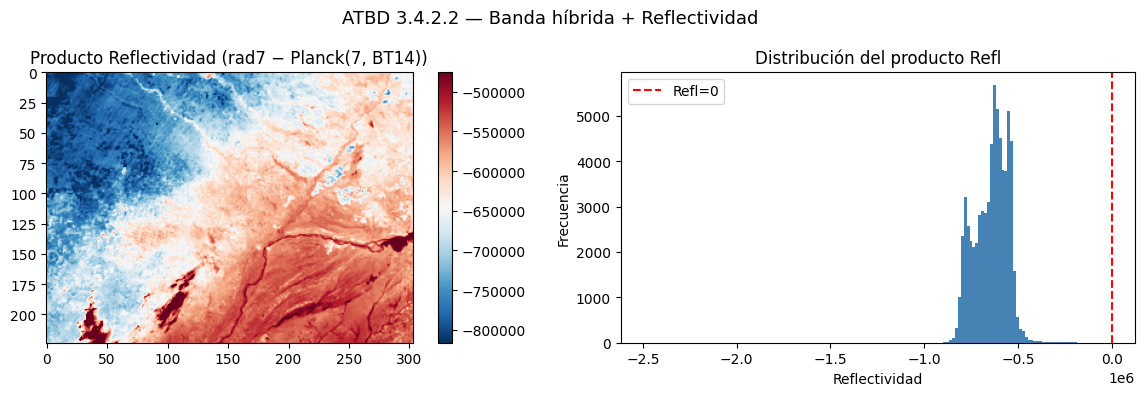

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

refl_plot = refl.copy()
im0 = axes[0].imshow(refl_plot, cmap='RdBu_r', origin='upper',
                     vmin=np.nanpercentile(refl_plot, 1),
                     vmax=np.nanpercentile(refl_plot, 99))
plt.colorbar(im0, ax=axes[0])
axes[0].set_title('Producto Reflectividad (rad7 − Planck(7, BT14))')

axes[1].hist(refl_plot[np.isfinite(refl_plot)].ravel(), bins=150, color='steelblue', edgecolor='none')
axes[1].set_xlabel('Reflectividad')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución del producto Refl')
axes[1].axvline(0, color='red', linestyle='--', label='Refl=0')
axes[1].legend()

plt.suptitle('ATBD 3.4.2.2 — Banda híbrida + Reflectividad', fontsize=13)
plt.tight_layout()
plt.show()

---
## Paso 3 — ATBD 3.4.2.3: Tests de geometría y nube. PRIMER FILTRO GRUESO.

Aplicamos los filtros de **descarte rápido** sobre toda la grilla y asignamos un código en `fire_mask`. Mostramos cuántos píxeles quedan en cada categoría.

In [16]:
# ── ATBD 3.4.2.3 — Test data against thresholds──────────────────────────
fire_mask = np.full((L, W), FireMask.INIT, dtype=np.int32) # INIT o FIRE_FREE?
cloud_mask = np.zeros((L, W), dtype=bool)

# 1. Space (NaN en BT7) 
space = np.isnan(inp.bt7)
fire_mask[space] = FireMask.SPACE

remaining = fire_mask == FireMask.INIT

# 2. Local zenith angle
zenith_block = remaining & (inp.lza > MAX_LOCAL_ZENITH)
fire_mask[zenith_block] = FireMask.ZENITH_BLOCK

remaining = fire_mask == FireMask.INIT

# 3. Sun glint 
glint_block = remaining & ((inp.lza < GLINT_THRESHOLD) | (inp.glint_angle < GLINT_THRESHOLD)) #revisar si es sza o lza
fire_mask[glint_block] = FireMask.GLINT_BLOCK

is_day = (inp.sza >= 0.0) & (inp.sza <= MAX_SZA_DAYLIGHT)
# 3b. Canal 14 faltante (ATBD 3.4.2.3, código 121)
miss14 = remaining & np.isnan(bt14_eff)
fire_mask[miss14] = FireMask.MISS_CH14
remaining = fire_mask == FireMask.INIT

# 4. Saturation / unusable temperatures
sat7 = remaining & (inp.bt7 > SAT_TEMP_CH7 + SAT_BUFF)
fire_mask[sat7] = FireMask.SAT_CH7
remaining = fire_mask == FireMask.INIT

sat14 = remaining & (bt14_eff > SAT_TEMP_CH14 + SAT_BUFF)
fire_mask[sat14] = FireMask.SAT_CH14
remaining = fire_mask == FireMask.INIT

unus7 = remaining & (inp.bt7 < MIN_BT)
fire_mask[unus7] = FireMask.UNUS_CH7
remaining = fire_mask == FireMask.INIT

unus14 = remaining & (bt14_eff < MIN_BT)
fire_mask[unus14] = FireMask.UNUS_CH14
remaining = fire_mask == FireMask.INIT

# 5. Radiance quality
neg_rad = remaining & ((inp.rad7 < 0) | (rad14_eff < 0))
fire_mask[neg_rad] = FireMask.NEG_RAD
remaining = fire_mask == FireMask.INIT

# 6. Ecosystem masks
# Pixeles donde no se deberia buscar incendios porque son agua o desierto brillante
bad_eco = remaining & (np.isin(inp.land_cover, MODIS_WATER_CODES)| (inp.land_cover == UMD_WATER_CODE) | (inp.desert_mask == DESERT_BRIGHT))
fire_mask[bad_eco] = FireMask.BAD_ECOSYSTEM # Este filtro dice que se aplica a los vecinos tambien, faltaria ver eso
remaining = fire_mask == FireMask.INIT

sea = remaining & (inp.usgs_eco == USGS_SEA_WATER)
fire_mask[sea] = FireMask.SEA_WATER
remaining = fire_mask == FireMask.INIT

coast = remaining & np.isin(inp.usgs_eco, USGS_COAST_FRINGE)
fire_mask[coast] = FireMask.COAST_FRINGE
remaining = fire_mask == FireMask.INIT

inland = remaining & np.isin(inp.usgs_eco, USGS_INLAND_WATER)
fire_mask[inland] = FireMask.INLAND_WATER
remaining = fire_mask == FireMask.INIT

# 7. Minimum BT difference (ATBD: primero fire-free/100, después too-cold/201)
diff = inp.bt7 - bt14_eff
fire_free = (remaining & (np.abs(diff) <= CH_DIFF) & ((inp.bt7 > BRIGHTNESS_THRESHOLD) | (bt14_eff > BRIGHTNESS_THRESHOLD)))
fire_mask[fire_free] = FireMask.FIRE_FREE
remaining = fire_mask == FireMask.INIT

too_cold = (remaining & (np.abs(diff) < CH_DIFF) & ((inp.bt7 <= BRIGHTNESS_THRESHOLD) | (bt14_eff <= BRIGHTNESS_THRESHOLD)))
fire_mask[too_cold] = FireMask.TOO_COLD
remaining = fire_mask == FireMask.INIT

# 8. Dynamic thresholds que dependen de la hora del día
bt7_min = np.full(inp.bt7.shape, BT7_MIN_NIGHT)
bt7_refl_thr = np.full(inp.bt7.shape, BT7_REFL_THRESH_NIGHT)

cos_sza = np.cos(np.deg2rad(inp.sza))

bt7_min[is_day] = BT7_MIN_NIGHT + BT7_MIN_SOLAR_COEF * cos_sza[is_day]
bt7_refl_thr[is_day] = BT7_REFL_THRESH_NIGHT + BT7_REFL_THRESH_SOLAR * cos_sza[is_day]


# 9. Cloud tests
# los tests de nube NO sacan al píxel de carrera (ATBD 3.4.2.3)
cloud_bt14 = remaining & (bt14_eff < CLOUD_BT14_THRESH)
fire_mask[cloud_bt14] = FireMask.CLOUD_BT14
cloud_mask[cloud_bt14] = True

cloud_bt7_bt14_neg = remaining & ((inp.bt7 - bt14_eff) < CLOUD_BT7_BT14_NEG)
fire_mask[cloud_bt7_bt14_neg] = FireMask.CLOUD_BT14_BT15_NEG  
cloud_mask[cloud_bt7_bt14_neg] = True

cloud_bt7_bt14_pos = remaining & ((inp.bt7 - bt14_eff) > CLOUD_BT7_BT14_POS) & (inp.bt7 < CLOUD_BT7_FOR_POS)
fire_mask[cloud_bt7_bt14_pos] = FireMask.CLOUD_BT7_BT14_POS
cloud_mask[cloud_bt7_bt14_pos] = True

cloud_albedo = np.zeros((L, W), dtype=bool)
if inp.refl2 is not None:
    geom = ((inp.sza <= 70) | ((inp.sza <= 60) & (inp.lza <= 60)))
    cloud_albedo = remaining & is_day & geom & np.isfinite(albedo) & (albedo > CLOUD_ALBEDO_THRESH)
    fire_mask[cloud_albedo] = FireMask.CLOUD_ALBEDO
    cloud_mask[cloud_albedo] = True

cloud_bt15        = np.zeros((L, W), dtype=bool)
cloud_bt1415_neg  = np.zeros((L, W), dtype=bool)
cloud_bt1415_pos  = np.zeros((L, W), dtype=bool)
if inp.bt15 is not None:
    cloud_bt15 = remaining & (inp.bt15 <= CLOUD_BT15_THRESH)
    fire_mask[cloud_bt15] = FireMask.CLOUD_BT15
    cloud_mask[cloud_bt15] = True

    diff15 = bt14_eff - inp.bt15
    scope15 = remaining & (bt14_eff < CLOUD_BT14_THRESH)

    cloud_bt1415_neg = scope15 & (diff15 < CLOUD_BT14_BT15_NEG)
    fire_mask[cloud_bt1415_neg] = FireMask.CLOUD_BT14_BT15_NEG
    cloud_mask[cloud_bt1415_neg] = True

    cloud_bt1415_pos = scope15 & (diff15 > CLOUD_BT14_BT15_POS)
    fire_mask[cloud_bt1415_pos] = FireMask.CLOUD_BT14_BT15_POS
    cloud_mask[cloud_bt1415_pos] = True

# 'remaining' NO se reduce por los tests de nube: los pixeles nublados siguen
# en carrera para 3.4.2.4 y las etapas siguientes ("cloudy pixels MAY be
# found to contain fires later", ATBD 3.4.2.3)
categories = {
    'SPACE'                    : int(space.sum()),
    'ZENITH_BLOCK'             : int(zenith_block.sum()),
    'GLINT_BLOCK (bruto)*'     : int(glint_block.sum()),
    'MISS_CH14'                : int(miss14.sum()),
    'SAT_CH7'                  : int(sat7.sum()),
    'SAT_CH14'                 : int(sat14.sum()),
    'UNUS_CH7'                 : int(unus7.sum()),
    'UNUS_CH14'                : int(unus14.sum()),
    'BAD_ECOSYSTEM'            : int(bad_eco.sum()),
    'SEA_WATER'                : int(sea.sum()),
    'COAST_FRINGE'             : int(coast.sum()),
    'INLAND_WATER'             : int(inland.sum()),
    'NEG_RAD'                  : int(neg_rad.sum()),
    'FIRE_FREE'                : int(fire_free.sum()),
    'TOO_COLD'                 : int(too_cold.sum()),
    'CLOUD (union, algun test)': int(cloud_mask.sum()),
    '  · CLOUD_BT14'           : int(cloud_bt14.sum()),
    '  · CLOUD_BT7-BT14 neg'   : int(cloud_bt7_bt14_neg.sum()),
    '  · CLOUD_BT7-BT14 pos'   : int(cloud_bt7_bt14_pos.sum()),
    '  · CLOUD_ALBEDO'         : int(cloud_albedo.sum()),
    '  · CLOUD_BT15'           : int(cloud_bt15.sum()),
    '  · CLOUD_BT14-BT15 neg'  : int(cloud_bt1415_neg.sum()),
    '  · CLOUD_BT14-BT15 pos'  : int(cloud_bt1415_pos.sum()),
    'Candidatos restantes ("remaining")': int(remaining.sum()),
}

df_geo = pd.DataFrame(categories.items(), columns=['Estado', 'N pixeles'])
df_geo['% total'] = (df_geo['N pixeles'] / (L * W) * 100).round(2)
print(df_geo.to_string(index=False))


                            Estado  N pixeles  % total
                             SPACE          0     0.00
                      ZENITH_BLOCK          0     0.00
              GLINT_BLOCK (bruto)*          0     0.00
                         MISS_CH14          0     0.00
                           SAT_CH7          0     0.00
                          SAT_CH14          0     0.00
                          UNUS_CH7          0     0.00
                         UNUS_CH14          0     0.00
                     BAD_ECOSYSTEM          0     0.00
                         SEA_WATER          0     0.00
                      COAST_FRINGE          0     0.00
                      INLAND_WATER          0     0.00
                           NEG_RAD          0     0.00
                         FIRE_FREE      10142    14.94
                          TOO_COLD          0     0.00
         CLOUD (union, algun test)         94     0.14
                      · CLOUD_BT14          0     0.00
          

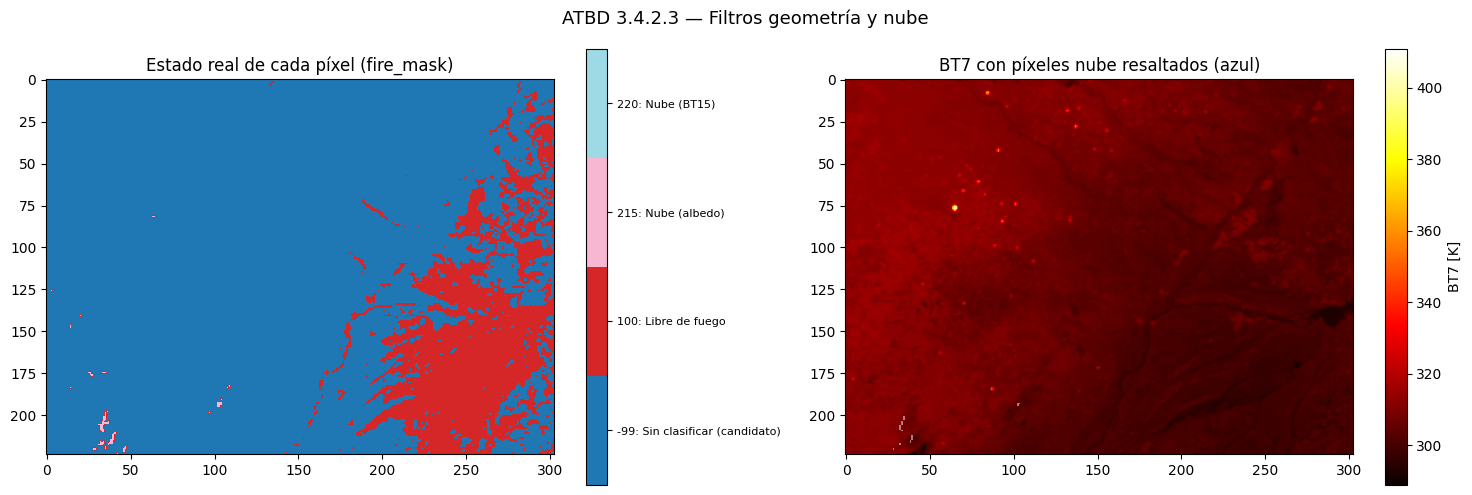

In [17]:
# Construimos el mapa de estado directamente desde fire_mask 
codes_present = sorted(np.unique(fire_mask).tolist())

code_names = {
    FireMask.SPACE: 'Espacio',
    FireMask.ZENITH_BLOCK: 'Zenith',
    FireMask.GLINT_BLOCK: 'Glint',
    FireMask.CLOUD_BT14: 'Nube (BT14)',
    FireMask.CLOUD_BT7_BT14_NEG: 'Nube (BT7-BT14 neg)',
    FireMask.CLOUD_BT7_BT14_POS: 'Nube (BT7-BT14 pos)',
    FireMask.CLOUD_ALBEDO: 'Nube (albedo)',
    FireMask.CLOUD_BT15: 'Nube (BT15)',
    FireMask.CLOUD_BT14_BT15_NEG: 'Nube (BT14-BT15 neg)',
    FireMask.CLOUD_BT14_BT15_POS: 'Nube (BT14-BT15 pos)',
    FireMask.SAT_CH7: 'Saturado CH7',
    FireMask.SAT_CH14: 'Saturado CH14',
    FireMask.NEG_RAD: 'Radiancia negativa',
    FireMask.UNUS_CH7: 'CH7 no usable',
    FireMask.UNUS_CH14: 'CH14 no usable',
    FireMask.FIRE_FREE: 'Libre de fuego',
    FireMask.INIT: 'Sin clasificar (candidato)',
}

n = len(codes_present)
cmap = plt.get_cmap('tab20', n)
code_to_idx = {c: i for i, c in enumerate(codes_present)}
idx_map = np.vectorize(code_to_idx.get)(fire_mask)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

im = axes[0].imshow(idx_map, cmap=cmap, vmin=-0.5, vmax=n - 0.5, origin='upper')
cbar = plt.colorbar(im, ax=axes[0], ticks=range(n))
cbar.ax.set_yticklabels([f'{c}: {code_names.get(c, "?")}' for c in codes_present], fontsize=8)
axes[0].set_title('Estado real de cada píxel (fire_mask)')

im1 = axes[1].imshow(inp.bt7, cmap='hot', origin='upper')
plt.colorbar(im1, ax=axes[1], label='BT7 [K]')
cloud_overlay = np.ma.masked_where(~cloud_mask, cloud_mask)
axes[1].imshow(cloud_overlay, cmap='Blues', alpha=0.5, origin='upper')
axes[1].set_title('BT7 con píxeles nube resaltados (azul)')

plt.suptitle('ATBD 3.4.2.3 — Filtros geometría y nube', fontsize=13)
plt.tight_layout()
plt.show()

# # --- Grid con TODAS las máscaras booleanas individuales ---
# all_masks = {
#     'space': space,
#     'is_day': is_day,
#     'glint_block': glint_block,
#     'zenith_block': zenith_block,
#     'too_cold': too_cold,
#     'fire_free': fire_free,
#     'sat7': sat7,
#     'sat14': sat14,
#     'rad_invalid': neg_rad,
#     'unus7': unus7,
#     'unus14': unus14,
#     'cloud_cold': cloud_bt14,
#     'cloud_alb': cloud_albedo,
#     'cloud_mask (acumulada)': cloud_mask,
# }

# ncols = 4
# nrows = int(np.ceil(len(all_masks) / ncols))
# fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
# axes = axes.flatten()

# for ax, (name, mask) in zip(axes, all_masks.items()):
#     ax.imshow(mask, cmap='Greys', origin='upper', vmin=0, vmax=1)
#     ax.set_title(f'{name}\n(n={int(mask.sum())})', fontsize=9)
#     ax.set_xticks([]); ax.set_yticks([])

# for ax in axes[len(all_masks):]:
#     ax.axis('off')

# plt.suptitle('Todas las máscaras booleanas — Paso 3 (geometría/nube)', fontsize=13)
# plt.tight_layout()
# plt.show()

---
## Paso 3.5 — ATBD 3.4.2.4: Test along-scan de reflectividad + flag de saturación

Antes de calcular el background, el algoritmo aplica un **test de reflectividad along-scan**: compara el producto `Refl` del píxel actual con el de los píxeles ubicados 3 posiciones a la izquierda (`Refl-3`) y 3 a la derecha (`Refl+3`) en la misma línea de escaneo, para detectar bordes de nube cercanos. Actúa como un filtro de nubes y bordes de nubes que podrían confundirse con incendios debido a su alta reflectividad.

- **Nocturno** (o diurno sin albedo válido): si `BT7 < BT7_min` y `BT7 ≥ MIN_BT`, y (`Refl-3 < 0.2` o `Refl+3 < 0.2`) → `FireMask.ALONG_SCAN_NIGHT` (código 240), el píxel se descarta.
- **Diurno** (con albedo válido): si `Albedo ≥ 0.38` y `BT7 < 320 K`, y (`Refl-3 < 0.2` o `Refl+3 < 0.2`) → `FireMask.ALONG_SCAN_DAY` (código 245), el píxel se descarta.

**Importante:** este test corre sobre los píxeles que pasaron los filtros rápidos, *incluyendo los marcados como nube* en §3.4.2.3 — el ATBD dice explícitamente que esos píxeles "pueden ser encontrados como fuego más adelante", así que todavía no se descartan. 

Inmediatamente después (todavía dentro del texto de la sección 3.4.2.4 del ATBD, antes de pasar a 3.4.2.5) se evalúa el **flag de saturación**: si `BT7 ≥ SAT_FLAG_CH7` (411.76 K) o `BT14 ≥ SAT_FLAG_CH14` (339.90 K) se marca `sat_flag=True` y se asigna `FailChar = 7` (Tabla 3.5). A diferencia del test `SAT_CH7`/`SAT_CH14` de la sección 3.4.2.3 (que usa un buffer de 5 K y **descarta** el píxel), este umbral es más ajustado (saturación real − 0.1 K) y **no descarta** el píxel — sólo lo marca para saltarse más adelante la caracterización sub-píxel (Dozier).


In [18]:
# ── ATBD 3.4.2.4: test along-scan de reflectividad ─────────────────────────

# Vecinos a 3 posiciones en la misma fila (scan), con clamp de borde (no wrap-around) para no unir erroneamente este con oeste
idx        = np.arange(W)
idx_left   = np.clip(idx - 3, 0, W - 1)
idx_right  = np.clip(idx + 3, 0, W - 1)
refl_left  = refl[:, idx_left]
refl_right = refl[:, idx_right]

# Rama diurna vs. nocturna: mutuamente excluyentes
# En la documentacion no se aclara qué se hace si es de día pero refl no está disponible
night_test = remaining & ~is_day & (inp.bt7 < bt7_min) & (inp.bt7 >= MIN_BT7) 
day_test   = remaining &  is_day & np.isfinite(albedo) & (albedo >= CLOUD_ALBEDO_THRESH) & (inp.bt7 < MAX_BT7)

suspicious_neighbour = (refl_left < MIN_REFL) | (refl_right < MIN_REFL)

along_scan_night = night_test & suspicious_neighbour
fire_mask[along_scan_night] = FireMask.ALONG_SCAN_NIGHT

along_scan_day = day_test & suspicious_neighbour
fire_mask[along_scan_day] = FireMask.ALONG_SCAN_DAY

# Estos códigos sí sacan al píxel de carrera (ATBD: "proceeds to the next pixel")
remaining = remaining & ~(along_scan_night | along_scan_day) # PERO no hay que hacer INIT, porque eso borraria nubes

# ── Flag de saturacion + FailChar = 7 (todavia ATBD 3.4.2.4) ───────────────
fail_char = np.full((L, W), FailChar.NONE, dtype=np.int32)

sat_flag = remaining & ((inp.bt7 >= SAT_FLAG_CH7) | (bt14_eff >= SAT_FLAG_CH14))
fail_char[sat_flag] = FailChar.F7

# ── Resumen ────────────────────────────────────────────────────────────────
categories_342_4 = {
    'Elegibles (día)'                      : int(day_test.sum()),
    'Elegibles (noche)'                    : int(night_test.sum()),
    'ALONG_SCAN_DAY (código 245)'          : int(along_scan_day.sum()),
    'ALONG_SCAN_NIGHT (código 240)'        : int(along_scan_night.sum()),
    'Candidatos restantes tras 3.4.2.4'    : int(remaining.sum()),
}
df_scan = pd.DataFrame(categories_342_4.items(), columns=['Estado', 'N píxeles'])
df_scan['% total'] = (df_scan['N píxeles'] / (L * W) * 100).round(2)
print(df_scan.to_string(index=False))

                           Estado  N píxeles  % total
                  Elegibles (día)         94     0.14
                Elegibles (noche)          0     0.00
      ALONG_SCAN_DAY (código 245)         94     0.14
    ALONG_SCAN_NIGHT (código 240)          0     0.00
Candidatos restantes tras 3.4.2.4      57636    84.92


---
## Paso 4a — ATBD 3.4.2.5: Background condition statistics

background.py es la implementación de ATBD §3.4.2.5: dado un píxel candidato, calcula "cómo se ve normalmente esa zona" (el fondo/background) para poder después decir si el píxel en cuestión se desvía lo suficiente como para sospechar fuego (eso ya es §3.4.2.6, que consume esta salida).

Para un píxel candidato de ejemplo, el algoritmo calcula estadísticas de fondo en una
**ventana dinámica** centrada en el píxel:

- Empieza en `half=5` (ventana 11×11) y se agranda de a `+5` en cada dirección por
  iteración, hasta un máximo de 10 iteraciones (ventana final 111×111).
- Un píxel de la ventana es **válido** si:
  - es tierra (`land_mask`),
  - **no** es anómalamente cálido: `BT7 > 310K` (`+25·cos(SZA)` de día),
  - **no** es frío: `BT7 < 270K` o `BT14 < 270K`,
  - y **no** es "reflectivo/nube": `vis < 1` (8-bit) o `Albedo ≥ 0.38`.
- Los píxeles fuera de imagen (borde) **cuentan en el denominador** de la ventana pero
  nunca son válidos (así, cerca del borde, converge más lento).
- Se agranda la ventana hasta que **>= 20%** de las posiciones de la ventana son válidas.
  Si se llega a 10 iteraciones sin lograrlo: `FireMask.NO_BACKGROUND` (código 170) y se
  pasa al siguiente píxel.
- Una vez satisfecho el 20%, se calculan dos enfoques para la media/std de BT7 y BT14:
  - **Estadístico**: media/std directas sobre los valores válidos.
  - **Histograma**: se arma un histograma de enteros de BT7−BT14, se toma el bin con
    mayor frecuencia ± 1 vecino, y se calcula media/std sobre ese subconjunto.
  - Se usa el enfoque con **menor std de BT7** para definir `Temp7_Bkg_Mean`,
    `Temp14_Bkg_Mean` y `Vis_Mean_Bkg` (Tabla 3.6).

**Nota:** el ATBD menciona un "offset = min(5, n_passes/3)" para ajustar por tamaño de
ventana, pero ese ajuste **no se aplica acá** — se aplica más adelante, en
`_contextual_thresholds` (§3.4.2.6), usando el `n_passes` que devuelve este paso.

In [19]:
# ── ATBD 3.4.2.5 — elegimos un pixel de ejemplo ────────────────
np.random.seed(7)
candidatos_342_5 = np.argwhere(remaining)
i0, j0 = candidatos_342_5[np.random.randint(len(candidatos_342_5))]
i0, j0 = int(i0), int(j0)

print(f'Pixel de ejemplo: (i={i0}, j={j0})  |  BT7={inp.bt7[i0,j0]:.1f}K  BT14={bt14_eff[i0,j0]:.1f}K  '
      f'is_day={bool(is_day[i0,j0])}')

trace = []
bkg = compute_background(
    i0, j0, inp.bt7, bt14_eff, refl, vis_brightness,
    albedo if inp.refl2 is not None else None,
    inp.land_mask, sza_cos, is_day,
    trace=trace,
)

if bkg is None:
    print("No se pudo calcular el fondo para el píxel de ejemplo.")


Pixel de ejemplo: (i=190, j=20)  |  BT7=307.9K  BT14=301.6K  is_day=True


In [20]:
# ── Conectar el trace con el resultado final devuelto por compute_background ──
enfoques = trace[-1]
usar_hist = enfoques['t7_hist_std'] < enfoques['t7_stat_std']
metodo = 'histograma' if usar_hist else 'estadistico'

print(f"Metodo elegido (menor std BT7): {metodo}")
print(f"  bkg.temp7_bkg_mean   = {bkg.temp7_bkg_mean:.2f} K")
print(f"  bkg.temp14_bkg_mean  = {bkg.temp14_bkg_mean:.2f} K")
print(f"  bkg.temp7_bkg_stddev = {bkg.temp7_bkg_stddev:.3f}")
print(f"  bkg.n_passes         = {bkg.n_passes}   (offset en 3.4.2.6 = min(5, n_passes/3) = {min(5, bkg.n_passes/3):.2f})")
print(f"  bkg.reflb            = {bkg.reflb:.4f}   (ventana completa, sin filtrar)")
print(f"  bkg.rad_diff_sigma   = {bkg.rad_diff_sigma:.4f}")

# Sanity check liviano: el metodo elegido en el trace coincide con lo que devolvio bkg
esperado_t7 = enfoques['t7_hist_mean'] if usar_hist else enfoques['t7_stat_mean']
assert abs(bkg.temp7_bkg_mean - esperado_t7) < 1e-4, "El metodo elegido en el trace no coincide con bkg.temp7_bkg_mean"
print("\n✅ bkg.temp7_bkg_mean coincide con el enfoque elegido segun el trace")

Metodo elegido (menor std BT7): histograma
  bkg.temp7_bkg_mean   = 310.85 K
  bkg.temp14_bkg_mean  = 303.08 K
  bkg.temp7_bkg_stddev = 1.214
  bkg.n_passes         = 0   (offset en 3.4.2.6 = min(5, n_passes/3) = 0.00)
  bkg.reflb            = -682440.4409   (ventana completa, sin filtrar)
  bkg.rad_diff_sigma   = 19918.5560

✅ bkg.temp7_bkg_mean coincide con el enfoque elegido segun el trace


In [21]:
df_iter = pd.DataFrame(trace[:-1])
print(df_iter.to_string(index=False))

 n_iter  half  window_size  n_valid  frac_valid  cumple_20pct
      0     5          121      121         1.0          True


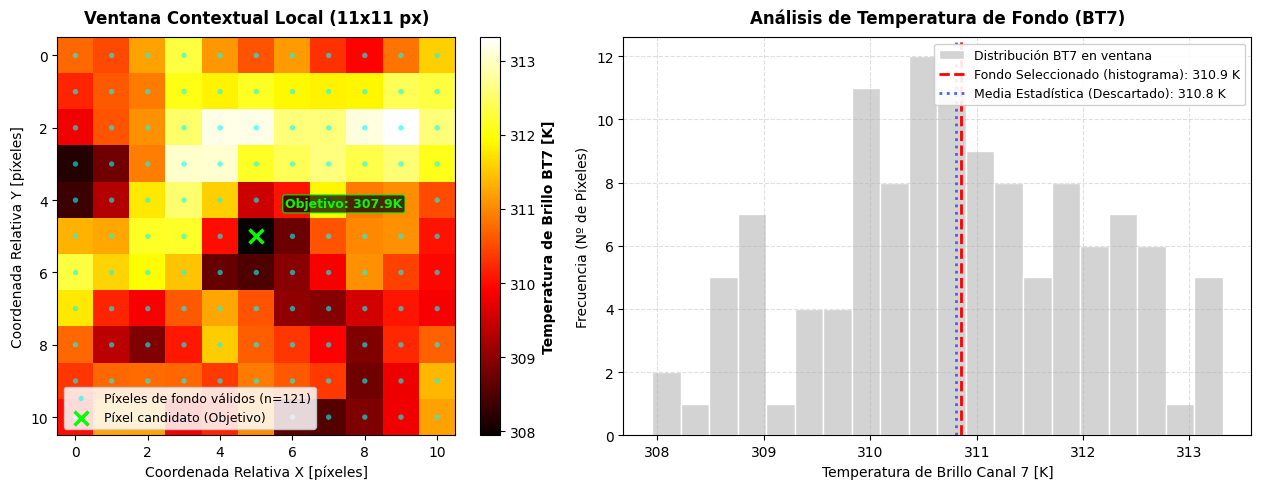

In [23]:
import numpy as np
import matplotlib.pyplot as plt

i_lo, i_hi, j_lo, j_hi = enfoques['valid_bounds']
valid = enfoques['valid_mask']
vi, vj = np.where(valid)

# Crear figura con mejor resolución (dpi)
fig, ax = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

# ---------------------------------------------------------
# SUBPLOT 1: Ventana espacial
# ---------------------------------------------------------
im = ax[0].imshow(inp.bt7[i_lo:i_hi+1, j_lo:j_hi+1], cmap='hot', origin='upper')

# Añadir barra de color para dar contexto térmico al mapa
cbar = fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
cbar.set_label('Temperatura de Brillo BT7 [K]', fontsize=10, fontweight='bold')

# Píxeles válidos y objetivo con etiquetas descriptivas
ax[0].scatter(vj, vi, s=15, c='cyan', alpha=0.6, edgecolors='none', 
              label=f'Píxeles de fondo válidos (n={valid.sum()})')

i_obj, j_obj = j0 - j_lo, i0 - i_lo
ax[0].scatter([i_obj], [j_obj], s=100, c='lime', marker='x', linewidths=2.5, 
              label='Píxel candidato (Objetivo)')

# Anotación directa sobre el píxel objetivo
val_target = inp.bt7[i0, j0]
ax[0].annotate(f'Objetivo: {val_target:.1f}K', 
                xy=(i_obj, j_obj), xytext=(i_obj + 0.8, j_obj - 0.8),
                color='lime', fontweight='bold', fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.7, ec="lime"))

ax[0].set_title(f"Ventana Contextual Local ({bkg.half_width*2+1}x{bkg.half_width*2+1} px)", 
                fontsize=12, fontweight='bold', pad=10)
ax[0].set_xlabel("Coordenada Relativa X [píxeles]", fontsize=10)
ax[0].set_ylabel("Coordenada Relativa Y [píxeles]", fontsize=10)
ax[0].legend(fontsize=9, loc='lower left', framealpha=0.85)
ax[0].grid(False)


# ---------------------------------------------------------
# SUBPLOT 2: Histograma de temperaturas
# ---------------------------------------------------------
n, bins, patches = ax[1].hist(enfoques['bt7_vals'], bins=20, color='lightgray', 
                              edgecolor='white', label='Distribución BT7 en ventana')

# Líneas de referencia con descripciones claras en la leyenda
val_elegido = bkg.temp7_bkg_mean
val_est = enfoques['t7_stat_mean']

ax[1].axvline(val_elegido, color='red', linestyle='--', linewidth=2,
              label=f'Fondo Seleccionado ({metodo}): {val_elegido:.1f} K')
ax[1].axvline(val_est, color='royalblue', linestyle=':', linewidth=2,
              label=f'Media Estadística (Descartado): {val_est:.1f} K')

# Anotación contextual indicando la discrepancia si existen ambas
diff = abs(val_elegido - val_est)
ax[1].set_title('Análisis de Temperatura de Fondo (BT7)', fontsize=12, fontweight='bold', pad=10)
ax[1].set_xlabel('Temperatura de Brillo Canal 7 [K]', fontsize=10)
ax[1].set_ylabel('Frecuencia (Nº de Píxeles)', fontsize=10)
ax[1].legend(fontsize=9, loc='upper right', framealpha=0.9)
ax[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [25]:
pip install ipywidgets

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]3 [ipywidgets]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from fdca.background import compute_background
from tqdm import tqdm

bkg_map = np.full((L, W), None, dtype=object)

# Solo calculamos background para píxeles que siguen "vivos" tras 3.4.2.1-3.4.2.4
# (igual que part1.py: el resto nunca llega a esta sección del algoritmo).
# Sin trace: para todo el dominio, trace es demasiado pesado en memoria —
# trace queda reservado para la celda de inspección de un píxel de ejemplo.
coords_vivos = np.argwhere(remaining)

for i, j in tqdm(coords_vivos, desc="3.4.2.5 — background para píxeles vivos"):
    i, j = int(i), int(j)

    bkg = compute_background(
        i, j, inp.bt7, bt14_eff, refl, vis_brightness,
        albedo if inp.refl2 is not None else None,
        inp.land_mask, sza_cos, is_day,
    )

    if bkg is None:
        fire_mask[i, j] = FireMask.NO_BACKGROUND
        remaining[i, j] = False
        continue

    bkg_map[i, j] = bkg

print(f"Background calculado para {int((bkg_map != None).sum()):,} de {len(coords_vivos):,} píxeles vivos")


# from fdca.background import compute_background

# # Calcular bkg por pixel
# bkg_map = np.full((L, W), None, dtype=object)
# coords_vivos = np.argwhere(remaining)

# prev_j_bkg = None
# prev_bkg = None

# for i in range(L):
#     for j in range(W):
#         if prev_j_bkg == j and prev_bkg is not None:
#             bkg = prev_bkg
#         else:
#             bkg = compute_background(
#                     i, j, inp.bt7, bt14_eff, refl, vis_brightness,
#                     albedo if inp.refl2 is not None else None,
#                     inp.land_mask, sza_cos, is_day,
#                     trace=None, #pa que no explote
# )

#             if bkg is None:
#                 # Abort del píxel: se marca como no-background y se pasa al siguiente
#                 fire_mask[i, j] = FireMask.NO_BACKGROUND
#                 remaining[i, j] = False

#             prev_j_bkg = j
#             prev_bkg = bkg

#         bkg_map[i, j] = bkg

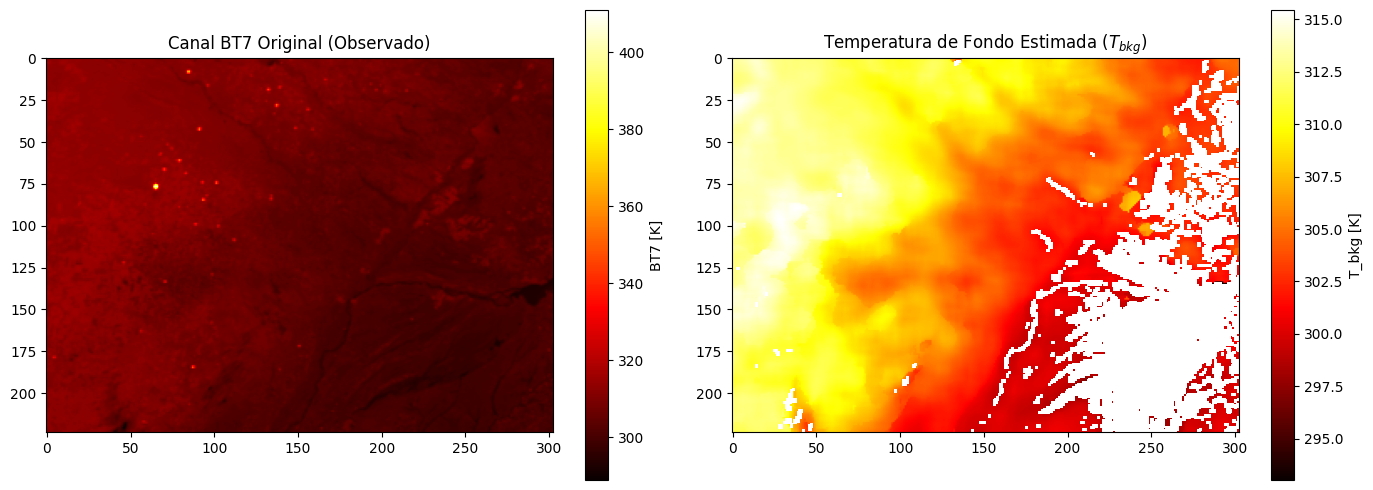

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Extraer solo la temperatura elegida de cada objeto 'bkg'
bkg_temp_grid = np.full(inp.bt7.shape, np.nan)

for (i, j), bkg in np.ndenumerate(bkg_map):
    if bkg is not None:
        bkg_temp_grid[i, j] = bkg.temp7_bkg_mean

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Canal BT7 original (con píxeles candidatos)
im0 = ax[0].imshow(inp.bt7, cmap='hot')
ax[0].set_title("Canal BT7 Original (Observado)")
fig.colorbar(im0, ax=ax[0], label="BT7 [K]")

# Temperatura de fondo calculada
im1 = ax[1].imshow(bkg_temp_grid, cmap='hot')
ax[1].set_title("Temperatura de Fondo Estimada ($T_{bkg}$)")
fig.colorbar(im1, ax=ax[1], label="T_bkg [K]")

plt.tight_layout()
plt.show()

Muestra la superficie continua de temperaturas de fondo estimadas en todo el dominio espacial. Permite verificar a simple vista si el fondo refleja la gradiente térmica natural de la zona (ej. zonas más frías por vegetación/agua vs. zonas más cálidas por suelo desnudo/desierto).

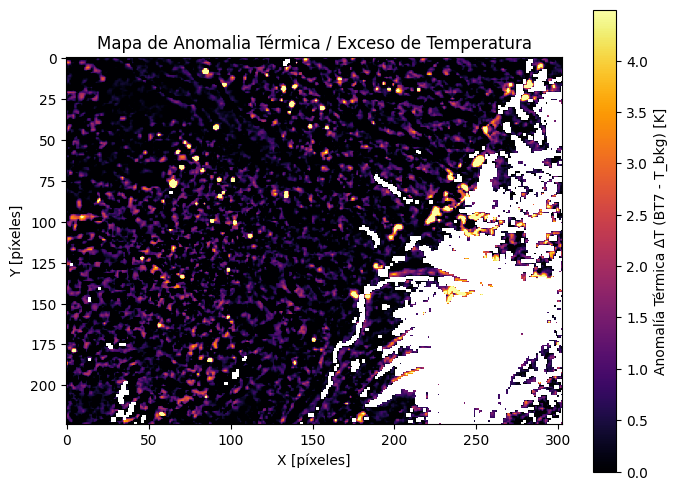

In [29]:
# Calcular el delta de temperatura para los píxeles analizados
delta_t = inp.bt7 - bkg_temp_grid

plt.figure(figsize=(8, 6))
im = plt.imshow(delta_t, cmap='inferno', vmin=0, vmax=np.nanpercentile(delta_t, 99))
cbar = plt.colorbar(im, label="Anomalía Térmica ΔT (BT7 - T_bkg) [K]")
plt.title("Mapa de Anomalia Térmica / Exceso de Temperatura")
plt.xlabel("X [píxeles]")
plt.ylabel("Y [píxeles]")
plt.show()

Esta es la visualización más relevante para detección de incendios o anomalias térmicas. Muestra la diferencia entre la temperatura real observada por el satélite y la temperatura de fondo esperada.Los píxeles con $\Delta T \approx 0\text{ K}$ son fondo normal.Los píxeles con $\Delta T$ alto destacan claramente como verdaderos focos de calor/anomalías.

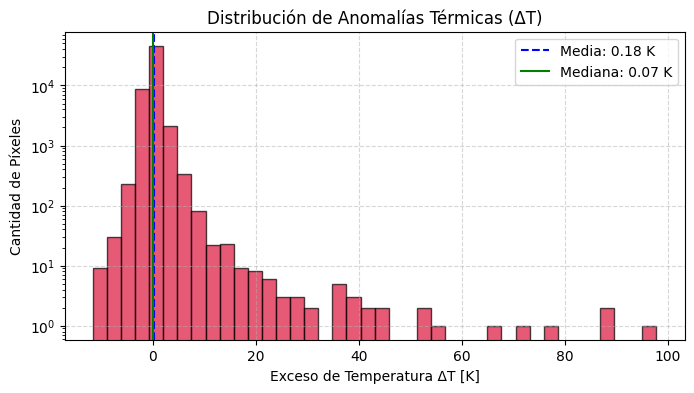

In [30]:
valid_deltas = delta_t[~np.isnan(delta_t)]

plt.figure(figsize=(8, 4))
plt.hist(valid_deltas, bins=40, color='crimson', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(valid_deltas), color='blue', linestyle='--', label=f'Media: {np.mean(valid_deltas):.2f} K')
plt.axvline(np.median(valid_deltas), color='green', linestyle='-', label=f'Mediana: {np.median(valid_deltas):.2f} K')

plt.title("Distribución de Anomalías Térmicas (ΔT)")
plt.xlabel("Exceso de Temperatura ΔT [K]")
plt.ylabel("Cantidad de Píxeles")
plt.yscale('log') # Escala logarítmica para ver fácilmente valores extremos/anomalías
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Ayuda a mostrar cuantitativamente la distribución de las anomalías en el conjunto total de píxeles procesados.

In [31]:
total_vivos = len(coords_vivos)
exitosos = np.count_nonzero(bkg_map != None)
fallidos = total_vivos - exitosos

print("="*50)
print(" RESUMEN DE CÁLCULO DE FONDO CONTEXTUAL (SECTION 3.4.2.5)")
print("="*50)
print(f"• Píxeles candidatos evaluados: {total_vivos:,}")
print(f"• Fondos calculados con éxito : {exitosos:,} ({exitosos/total_vivos*100:.1f}%)")
print(f"• Rechazados/Sin fondo (NO_BKG): {fallidos:,} ({fallidos/total_vivos*100:.1f}%)")

if exitosos > 0:
    deltas = delta_t[~np.isnan(delta_t)]
    print(f"• ΔT Promedio                  : {np.mean(deltas):.2f} K")
    print(f"• ΔT Máximo                    : {np.max(deltas):.2f} K")
print("="*50)

 RESUMEN DE CÁLCULO DE FONDO CONTEXTUAL (SECTION 3.4.2.5)
• Píxeles candidatos evaluados: 57,636
• Fondos calculados con éxito : 57,636 (100.0%)
• Rechazados/Sin fondo (NO_BKG): 0 (0.0%)
• ΔT Promedio                  : 0.18 K
• ΔT Máximo                    : 97.76 K


## ATBD 3.4.2.6

### Determine Contextual Thresholds (Intuición)

> Esta sección define la **regla de decisión**: *¿Qué tan "caliente" o "brillante" debe ser un píxel para dejar de considerarlo terreno normal y clasificarlo como un posible incendio?*


### 1. El Concepto de "Ruido de Fondo"
En la sección previa (`3.4.2.5`), calculaste la **media** ($\mu$) y la **desviación estándar** ($\sigma$) de los vecinos. Ahora usamos esa variación para definir un **margen de seguridad**:

* **Entorno uniforme ($\sigma$ baja):** El margen es pequeño; cualquier anomalía destaca rápidamente.
* **Entorno heterogéneo ($\sigma$ alta):** Terrenos mezclados (ej. rocas y vegetación) requieren un margen mayor para evitar falsas alarmas.



### 2. ¿Por qué se usan Multiplicadores? ($N \times \sigma$)
El algoritmo multiplica la desviación estándar por factores de corte (ej. $3.0\sigma$ o $3.75\sigma$).

$$\text{Umbral} = \mu_{\text{bkg}} + (k \cdot \sigma_{\text{bkg}})$$

* **Interpretación:** *"No me avises si el píxel es solo un poco más caliente que el promedio. Avísame solo si es al menos 3 o 4 veces más raro que la variación natural del paisaje."*


### 3. Límites de Seguridad: Suelos y Techos

Para evitar fallos en escenarios extremos, el algoritmo acota los umbrales contextuales dentro de un rango físico controlado (ej. entre $4.0\text{ K}$ y $10.0\text{ K}$):

| Rango | Nombre | Propósito Intuitivo |
| :--- | :--- | :--- |
| **Piso / Mínimo** | *Floor* | **Evita la hipersensibilidad.** Si el terreno es perfectamente uniforme ($\sigma \approx 0$), previene que el simple ruido numérico o del sensor active una alerta de fuego. |
| **Techo / Máximo** | *Ceiling* | **Evita la ceguera.** En terrenos ultra caóticos ($\sigma$ muy alta), evita que el umbral suba tanto que termine ignorando un incendio real. |


### 4. Test *Along Scan-Line* (Detector de Picos)
Es una prueba de **contraste local inmediato**. En lugar de mirar el promedio de toda la ventana, compara el píxel objetivo con sus vecinos adyacentes a lo largo de la línea de escaneo del satélite (2 o 3 píxeles a los lados).

> **Objetivo:** Identificar fuentes de calor puntuales (focos de incendio) marcadas como "picos" térmicos, diferenciándolas de cambios térmicos graduales en el clima o en el suelo.


### 5. El Factor Solar (Albedo de Fondo)
Durante el día, la radiación solar incidente refleja en la superficie y nubes, incrementando el brillo en la banda infrarroja de $3.9\,\mu\text{m}$ (BT7).

* **Lógica del filtro:** Separa la energía reflejada por el sol del calor emitido verdaderamente por combustión. Si un píxel es brillante pero su entorno también lo es por luz solar, el algoritmo ajusta la regla para no marcarlo como fuego.


> **Conclusión de esta etapa:**  
> La sección `3.4.2.6` **no clasifica aún el fuego**; ajusta dinámicamente la sensibilidad del detector para cada píxel según su contexto espacial y solar.

In [ ]:
# ── ATBD 3.4.2.6 — Determine contextual thresholds ─────────────────────
from fdca.part1 import _contextual_thresholds

coords_con_bkg = np.argwhere(bkg_map != None)
print(f'Píxeles con background disponible: {len(coords_con_bkg):,}')

records = []
for i, j in coords_con_bkg:
    i, j = int(i), int(j)
    bkg = bkg_map[i, j]
    sc  = sza_cos[i, j]
    std_7b14b, std_7b, std_reflb, std_reflb_max = _contextual_thresholds(bkg, sc)
    records.append({
        'i': i, 'j': j,
        'bt7_bkg': bkg.temp7_bkg_mean,
        'bt14_bkg': bkg.temp14_bkg_mean,
        'n_passes': bkg.n_passes,
        'std_7b': std_7b,
        'std_7b14b': std_7b14b,
        'std_reflb': std_reflb,
        'std_reflb_max': std_reflb_max,
    })

df_thresh = pd.DataFrame(records)
print(f'\nUmbrales contextuales calculados para {len(df_thresh):,} píxeles')
df_thresh[['bt7_bkg', 'bt14_bkg', 'n_passes', 'std_7b', 'std_7b14b',
           'std_reflb', 'std_reflb_max']].describe().round(3)


Píxeles con background disponible: 57,636

Umbrales contextuales calculados para 57,636 píxeles


,bt7_bkg,bt14_bkg,n_passes,std_7b,std_7b14b,std_reflb,std_reflb_max
count,57636.000,57636.000,57636.0,57636.000,57636.000,57636.0,57636.0
mean,306.973,302.002,0.0,4.304,1.929,1.0,10.0
std,4.572,3.021,0.0,0.674,0.996,0.0,0.0
min,293.023,290.452,0.0,4.000,0.388,1.0,10.0
25%,303.109,299.938,0.0,4.000,1.191,1.0,10.0
50%,306.892,301.547,0.0,4.000,1.612,1.0,10.0
75%,311.149,304.652,0.0,4.319,2.416,1.0,10.0
max,315.450,308.117,0.0,10.000,4.000,1.0,10.0


In [37]:
from fdca.part1 import _contextual_thresholds, _along_scan_reflectivity_test, _background_albedo
from fdca.constants import BT7_REFL_THRESH_NIGHT, BT7_REFL_THRESH_SOLAR

coords_con_bkg = np.argwhere(bkg_map != None)
print(f'Píxeles con background disponible: {len(coords_con_bkg):,}')

records = []
for i, j in coords_con_bkg:
    i, j = int(i), int(j)
    bkg = bkg_map[i, j]
    sc  = sza_cos[i, j]
    day_pixel = bool(is_day[i, j])

    std_7b14b, std_7b, std_reflb, std_reflb_max = _contextual_thresholds(bkg, sc)

    bt7_refl_thr = BT7_REFL_THRESH_NIGHT + (BT7_REFL_THRESH_SOLAR * sc if day_pixel else 0)
    pass_along = _along_scan_reflectivity_test(refl, i, j, W, std_reflb, inp.bt7[i, j], bt7_refl_thr)
    alb_bkg = _background_albedo(bkg.vis_mean_bkg, sc, day_pixel)

    records.append({
        'i': i, 'j': j,
        'bt7_bkg': bkg.temp7_bkg_mean, 'bt14_bkg': bkg.temp14_bkg_mean,
        'n_passes': bkg.n_passes,
        'std_7b': std_7b, 'std_7b14b': std_7b14b,
        'std_reflb': std_reflb, 'std_reflb_max': std_reflb_max,
        'pass_along': pass_along,
        'alb_bkg': alb_bkg,
    })

Píxeles con background disponible: 57,636


In [33]:
# Vista puntual: reusamos el mismo píxel de ejemplo (i0, j0) de 3.4.2.5

fila_ejemplo = df_thresh[(df_thresh.i == i0) & (df_thresh.j == j0)]
fila_ejemplo

,i,j,bt7_bkg,bt14_bkg,n_passes,std_7b,std_7b14b,std_reflb,std_reflb_max
49689,190,20,310.854034,303.081848,0,4.550971,1.887094,1.0,10.0


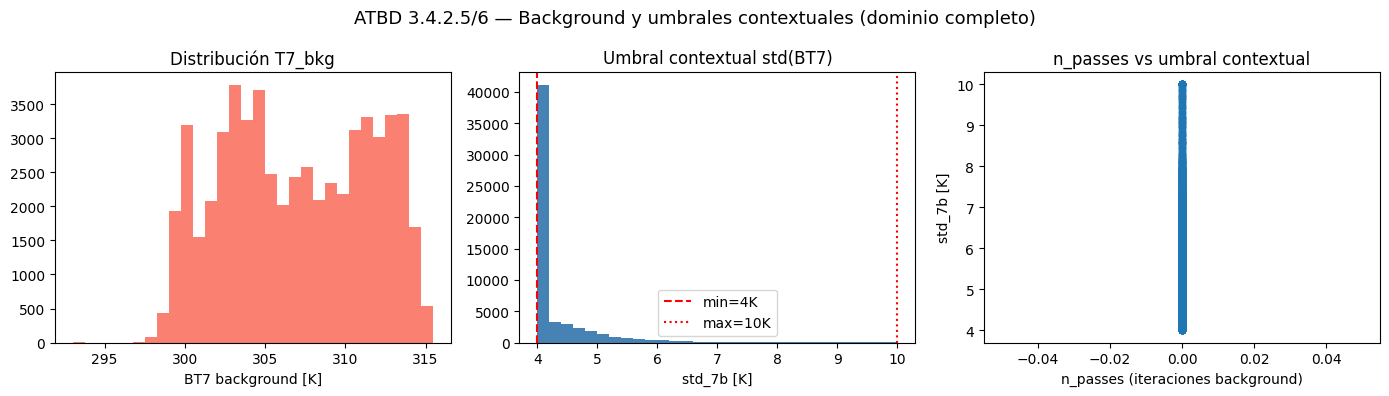

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df_thresh['bt7_bkg'], bins=30, color='salmon', edgecolor='none')
axes[0].set_xlabel('BT7 background [K]')
axes[0].set_title('Distribución T7_bkg')

axes[1].hist(df_thresh['std_7b'], bins=30, color='steelblue', edgecolor='none')
axes[1].axvline(4.0, color='red',  linestyle='--', label='min=4K')
axes[1].axvline(10.0, color='red', linestyle=':', label='max=10K')
axes[1].set_xlabel('std_7b [K]')
axes[1].set_title('Umbral contextual std(BT7)')
axes[1].legend()

axes[2].scatter(df_thresh['n_passes'], df_thresh['std_7b'], alpha=0.5, s=20)
axes[2].set_xlabel('n_passes (iteraciones background)')
axes[2].set_ylabel('std_7b [K]')
axes[2].set_title('n_passes vs umbral contextual')

plt.suptitle('ATBD 3.4.2.5/6 — Background y umbrales contextuales (dominio completo)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Paso 5 — ATBD 3.4.2.8: Correcciones TPW + emisividad + solar

Para un píxel de ejemplo con background válido, mostramos el efecto de cada corrección sobre las temperaturas de brillo.

In [71]:
# Elegir un píxel de la muestra con background válido
row0 = df_bkg.iloc[0]
i0, j0 = int(row0['i']), int(row0['j'])

# Recalcular background para ese píxel
bkg0 = compute_background(
    i0, j0,
    inp.bt7, bt14_eff, refl,
    vis_brightness,
    albedo if inp.refl2 is not None else None,
    inp.land_mask, sza_cos, is_day,
)

# Obtener coeficientes TPW LUT
col = _tpw_lut_indices(float(inp.tpw[i0, j0]), float(inp.lza[i0, j0]))
lut = inp.lut_tpw
trans7, trans14 = float(lut[2, col]), float(lut[3, col])
ext7,   ext14   = float(lut[4, col]), float(lut[5, col])

r7  = float(inp.rad7[i0, j0])
r14 = float(rad14_eff[i0, j0])

# Corrección TPW
r7_corr  = (r7  - ext7  * r7 ) / trans7
r14_corr = (r14 - ext14 * r14) / trans14
T7_corr  = float(planck_temp(7,  r7_corr))
T14_corr = float(planck_temp(14, r14_corr))

# Corrección emisividad
em7  = float(inp.emiss7 [i0, j0])
em14 = float(inp.emiss14[i0, j0])
r7_corr_em  = r7_corr  / em7
r14_corr_em = r14_corr / em14

# Background corregido
r7_bkg_raw   = planck_rad(7,  bkg0.temp7_bkg_mean)
r14_bkg_raw  = planck_rad(14, bkg0.temp14_bkg_mean)
r7_bkg_corr  = (r7_bkg_raw  - ext7  * r7_bkg_raw ) / trans7
r14_bkg_corr = (r14_bkg_raw - ext14 * r14_bkg_raw) / trans14

# Corrección solar
r7_solar_corr, rad7from14_bkg = _solar_correction(
    r7_corr_em, r7_bkg_corr, r14_bkg_corr, em7
)

# Corrección difracción
from fdca.constants import DIFFRAC_CH7_SUB, DIFFRAC_CH7_DIV, DIFFRAC_CH14_SUB, DIFFRAC_CH14_DIV
r7_diff  = (r7_solar_corr - DIFFRAC_CH7_SUB  * rad7from14_bkg) / DIFFRAC_CH7_DIV
r14_diff = (r14_corr      - DIFFRAC_CH14_SUB * r14_bkg_corr)   / DIFFRAC_CH14_DIV

T7c  = float(planck_temp(7,  r7_diff))
T14c = float(planck_temp(14, r14_diff))
Tbc  = float(planck_temp(7,  r7_bkg_corr))

summary = {
    'Paso': ['BT7 original', 'BT7 tras TPW', 'BT7 tras difracción',
              'BT14 original', 'BT14 tras TPW', 'BT14 tras difracción',
              'BT7_bkg (background)', 'BT7c_bkg (corregido)'],
    'Valor [K]': [
        float(inp.bt7[i0, j0]),
        T7_corr, T7c,
        float(bt14_eff[i0, j0]),
        T14_corr, T14c,
        float(bkg0.temp7_bkg_mean), Tbc,
    ]
}
df_corr = pd.DataFrame(summary)
df_corr['Valor [K]'] = df_corr['Valor [K]'].round(3)
print(f'Píxel ejemplo: ({i0}, {j0})  |  SZA={inp.sza[i0,j0]:.1f}°  |  TPW={inp.tpw[i0,j0]:.1f} mm')
print(f'trans7={trans7:.4f}  ext7={ext7:.4f}  em7={em7:.3f}\n')
print(df_corr.to_string(index=False))

TypeError: _solar_correction() missing 2 required positional arguments: 'coeffs7' and 'coeffs14'

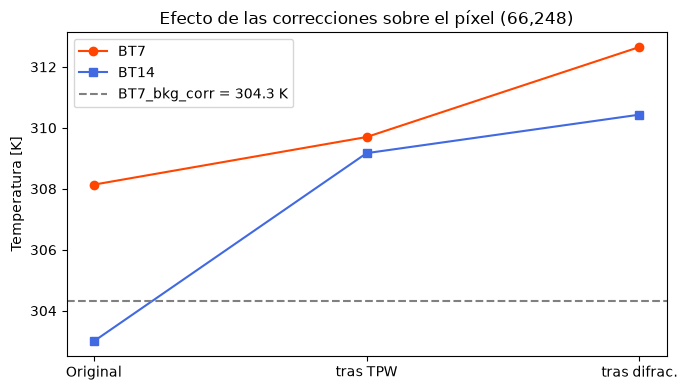

In [ ]:
etapas = ['Original', 'tras TPW', 'tras difrac.']
bt7_vals  = [float(inp.bt7[i0,j0]), T7_corr,  T7c]
bt14_vals = [float(bt14_eff[i0,j0]), T14_corr, T14c]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(etapas, bt7_vals,  'o-', color='orangered',   label='BT7')
ax.plot(etapas, bt14_vals, 's-', color='royalblue',   label='BT14')
ax.axhline(Tbc, color='gray', linestyle='--', label=f'BT7_bkg_corr = {Tbc:.1f} K')
ax.set_ylabel('Temperatura [K]')
ax.set_title(f'Efecto de las correcciones sobre el píxel ({i0},{j0})')
ax.legend()
plt.tight_layout()
plt.show()

---
## Paso 6 — ATBD 3.4.2.10: Dozier sub-pixel

Corremos `compute_dozier` para el mismo píxel ejemplo y mostramos la solución `(fire_temp, fire_frac, FRP)`.

In [ ]:
doz = compute_dozier(
    r7_diff, r14_diff,
    r7_bkg_corr, r14_bkg_corr,
    Tbc,
    is_potential_glint=False,
)

pix_area = compute_pixel_area(i0, j0, inp.latitudes, inp.longitudes)

print('=== Resultado Dozier ===')
print(f'  valid        : {doz.valid}')
print(f'  fire_temp    : {doz.fire_temp:.2f} K'  if not np.isnan(doz.fire_temp) else '  fire_temp: nan')
print(f'  fire_frac    : {doz.fire_frac:.6f}'    if doz.fire_frac is not None   else '  fire_frac: None')
print(f'  fail_char    : {doz.fail_char}')
print(f'  pixel_area   : {pix_area:.4f} km²')

if doz.valid and doz.fire_frac:
    frp_val = compute_frp(pix_area, r7_diff, r7_bkg_corr)
    fire_area = float(doz.fire_frac) * pix_area
    print(f'  fire_area    : {fire_area:.6f} km²')
    print(f'  FRP          : {frp_val:.4f} MW')

=== Resultado Dozier ===
  valid        : False
  fire_temp    : 337.01 K
  fire_frac    : 0.169956
  fail_char    : 6
  pixel_area   : 5.3451 km²


---
## Paso 7 — Correr `run_part1` completo y analizar resultados

In [ ]:
import time

# Obtener LUT y FPT desde el input
lut_tpw = getattr(inp, 'lut_tpw', np.ones((6, 35)))  # fallback si no existe
FPT     = getattr(inp, 'fpt', 0.0) or 0.0

t0 = time.time()
fire_mask_p1, fail_char_p1, candidates = run_part1(
    bt7=inp.bt7, rad7=inp.rad7,
    bt14=inp.bt14, rad14=inp.rad14,
    bt13=inp.bt13, rad13=inp.rad13,
    bt15=inp.bt15,
    refl2=inp.refl2,
    latitudes=inp.latitudes, longitudes=inp.longitudes,
    sza=inp.sza, glint_angle=inp.glint_angle,
    lza=inp.lza, azimuth=inp.azimuth,
    tpw=inp.tpw,
    emiss7=inp.emiss7, emiss14=inp.emiss14,
    lut_tpw=lut_tpw, FPT=FPT,
    land_cover=inp.land_cover, land_mask=inp.land_mask,
    desert_mask=inp.desert_mask, usgs_eco=inp.usgs_eco,
    data_quality=getattr(inp, 'data_quality', None),
)
elapsed = time.time() - t0

print(f'Part I completada en {elapsed:.1f} s')
print(f'Candidatos generados: {len(candidates):,}')

NameError: name 'refl2' is not defined

In [ ]:
# ── Resumen cuantitativo de fail_char ──────────────────────────────────────
vals, counts = np.unique(fail_char_p1[fail_char_p1 != FailChar.NONE], return_counts=True)
fc_names = {v: k for k, v in vars(FailChar).items() if not k.startswith('_') and isinstance(v, int)}

df_fc = pd.DataFrame({
    'fail_char'  : vals,
    'nombre'     : [fc_names.get(v, str(v)) for v in vals],
    'N píxeles'  : counts,
    '% candidatos': (counts / len(candidates) * 100).round(2) if len(candidates) > 0 else 0,
})
print('Distribución de fail_char entre candidatos de Part I:')
print(df_fc.to_string(index=False))

Distribución de fail_char entre candidatos de Part I:
 fail_char nombre  N píxeles  % candidatos
         3     F3          9          0.03
         4     F4      28965        107.26
         5     F5      12588         46.61
         6     F6      14798         54.80
         9     F9       1071          3.97
        10    F10         44          0.16


In [ ]:
# ── Tabla resumen de candidatos ─────────────────────────────────────────────
df_cand = pd.DataFrame([{
    'fire_id'   : c.fire_id,
    'lat'       : round(c.lat, 3),
    'lon'       : round(c.lon, 3),
    'bt7 [K]'   : round(c.bt7, 2),
    'bt14 [K]'  : round(c.bt14, 2),
    'bt7_bkg [K]': round(c.bt7_bkg, 2),
    'fire_temp [K]': round(c.fire_temp, 1) if not np.isnan(c.fire_temp) else np.nan,
    'fire_frac' : round(c.fire_frac, 6),
    'frp [MW]'  : round(c.frp, 3),
    'fail_char' : c.fail_char,
    'is_day'    : c.is_day,
} for c in candidates])

print(f'Primeros 20 candidatos (de {len(df_cand):,} total):')
print(df_cand.head(20).to_string(index=False))

Primeros 20 candidatos (de 27,005 total):
 fire_id   lat     lon  bt7 [K]  bt14 [K]  bt7_bkg [K]  fire_temp [K]  fire_frac  frp [MW]  fail_char  is_day
       1 -29.5 -58.560   313.97    307.84       313.29         -999.0        0.0     1.764          4    True
       2 -29.5 -58.536   313.55    307.70       313.22         -999.0        0.0     0.466          4    True
       3 -29.5 -58.467   313.13    307.32       312.97         -999.0        0.0    -0.281          4    True
       4 -29.5 -58.444   313.42    307.37       312.90         -999.0        0.0     0.902          4    True
       5 -29.5 -58.421   313.50    307.51       312.83         -999.0        0.0     1.380          4    True
       6 -29.5 -58.351   312.89    306.91       312.71         -999.0        0.0    -0.606          4    True
       7 -29.5 -58.328   313.37    307.16       312.69         -999.0        0.0     1.012          4    True
       8 -29.5 -58.258   312.56    306.66       312.42         -999.0        0

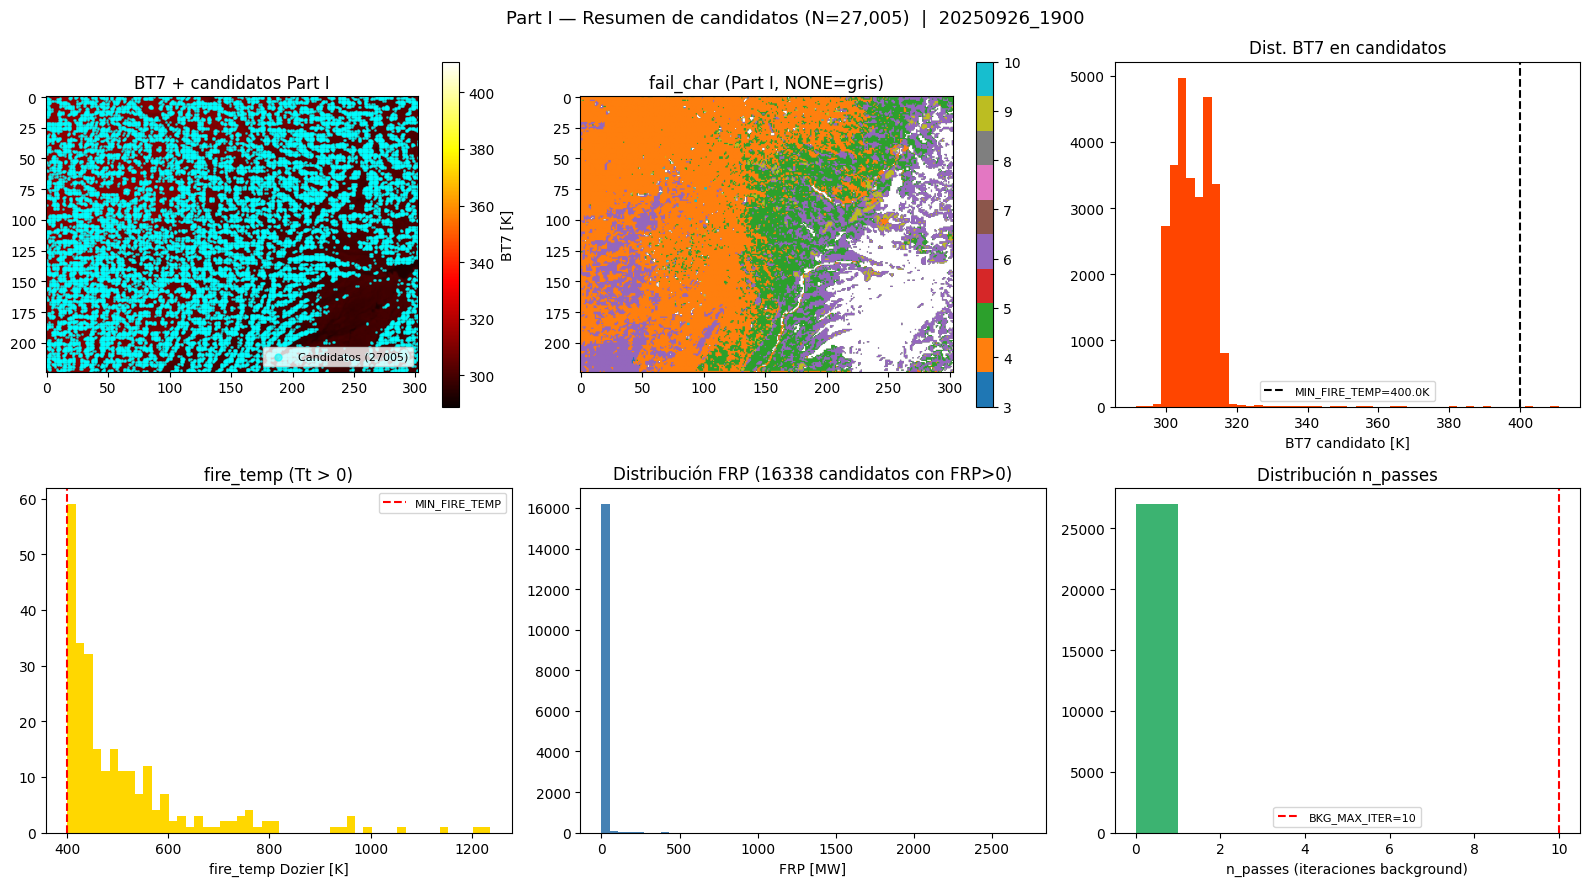

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1) BT7 con candidatos marcados
ax = axes[0, 0]
im = ax.imshow(inp.bt7, cmap='hot', origin='upper')
plt.colorbar(im, ax=ax, label='BT7 [K]')
if candidates:
    ci = [c.i for c in candidates]
    cj = [c.j for c in candidates]
    ax.scatter(cj, ci, s=1, c='cyan', alpha=0.6, label=f'Candidatos ({len(candidates)})')
ax.set_title('BT7 + candidatos Part I')
ax.legend(markerscale=5, fontsize=8)

# 2) fail_char map
ax = axes[0, 1]
fc_display = np.where(fail_char_p1 == FailChar.NONE, np.nan, fail_char_p1.astype(float))
im = ax.imshow(fc_display, cmap='tab10', origin='upper')
plt.colorbar(im, ax=ax)
ax.set_title('fail_char (Part I, NONE=gris)')

# 3) Distribución BT7 candidatos
ax = axes[0, 2]
if candidates:
    ax.hist([c.bt7 for c in candidates], bins=50, color='orangered', edgecolor='none')
    ax.axvline(MIN_FIRE_TEMP, color='k', linestyle='--', label=f'MIN_FIRE_TEMP={MIN_FIRE_TEMP}K')
ax.set_xlabel('BT7 candidato [K]')
ax.set_title('Dist. BT7 en candidatos')
ax.legend(fontsize=8)

# 4) fire_temp de Dozier (sólo válidos)
ax = axes[1, 0]
fire_temps = [c.fire_temp for c in candidates if c.fire_temp and c.fire_temp > 0]
if fire_temps:
    ax.hist(fire_temps, bins=50, color='gold', edgecolor='none')
    ax.axvline(MIN_FIRE_TEMP, color='r', linestyle='--', label=f'MIN_FIRE_TEMP')
ax.set_xlabel('fire_temp Dozier [K]')
ax.set_title('fire_temp (Tt > 0)')
ax.legend(fontsize=8)

# 5) FRP
ax = axes[1, 1]
frps = [c.frp for c in candidates if c.frp and c.frp > 0]
if frps:
    ax.hist(frps, bins=50, color='steelblue', edgecolor='none')
ax.set_xlabel('FRP [MW]')
ax.set_title(f'Distribución FRP ({len(frps)} candidatos con FRP>0)')

# 6) n_passes
ax = axes[1, 2]
npasses = [c.n_passes for c in candidates]
if npasses:
    ax.hist(npasses, bins=range(0, max(npasses)+2), color='mediumseagreen', edgecolor='none')
    ax.axvline(BKG_MAX_ITER, color='r', linestyle='--', label=f'BKG_MAX_ITER={BKG_MAX_ITER}')
ax.set_xlabel('n_passes (iteraciones background)')
ax.set_title('Distribución n_passes')
ax.legend(fontsize=8)

plt.suptitle(f'Part I — Resumen de candidatos (N={len(candidates):,})  |  {TIMESTAMP}', fontsize=13)
plt.tight_layout()
plt.show()

---
## Paso 8 — Mapa geográfico de candidatos

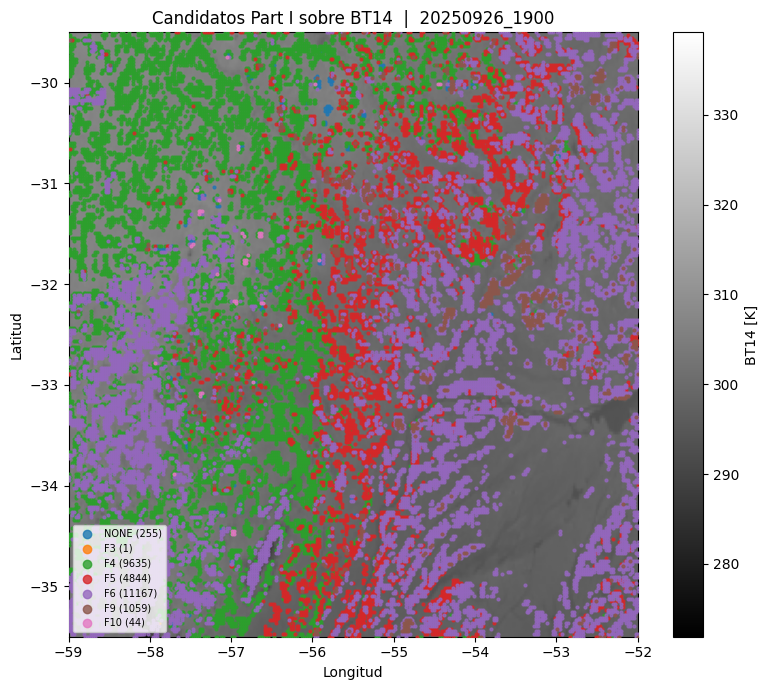

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

# BT14 como fondo
im = ax.imshow(
    bt14_eff,
    cmap='gray', origin='upper',
    extent=[inp.longitudes.min(), inp.longitudes.max(),
            inp.latitudes.min(),  inp.latitudes.max()],
    aspect='auto',
)
plt.colorbar(im, ax=ax, label='BT14 [K]')

# Candidatos por fail_char
fc_groups = {}
for c in candidates:
    fc = c.fail_char
    fc_groups.setdefault(fc, []).append((c.lon, c.lat))

colors_fc = plt.cm.tab10.colors
for idx, (fc, pts) in enumerate(sorted(fc_groups.items())):
    lons, lats = zip(*pts)
    label = fc_names.get(fc, str(fc))
    ax.scatter(lons, lats, s=4, color=colors_fc[idx % 10],
               alpha=0.8, label=f'{label} ({len(pts)})', zorder=5)

ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title(f'Candidatos Part I sobre BT14  |  {TIMESTAMP}')
ax.legend(fontsize=7, markerscale=3, loc='lower left')
plt.tight_layout()
plt.show()

---
## Paso 9 — Análisis de valores únicos en `fire_mask_p1` (diagnóstico §9.3)

In [ ]:
vals, counts = np.unique(fire_mask_p1, return_counts=True)
fm_names = {v: k for k, v in vars(FireMask).items() if not k.startswith('_') and isinstance(v, int)}

df_fm = pd.DataFrame({
    'fire_mask_val': vals,
    'nombre'       : [fm_names.get(v, str(v)) for v in vals],
    'N píxeles'    : counts,
    '% total'      : (counts / (L * W) * 100).round(3),
})
print('Distribución de valores en fire_mask_p1:')
print(df_fm.to_string(index=False))

# Verificación: ¿hay valores en rango 30-35 (temporales) en Part I? (no debería)
temporal_in_p1 = int(np.isin(fire_mask_p1, [30,31,32,33,34,35]).sum())
print(f'\nPíxeles 30-35 en fire_mask_p1 (debería ser 0): {temporal_in_p1}')

Distribución de valores en fire_mask_p1:
 fire_mask_val    nombre  N píxeles  % total
           -99      INIT      57730   85.057
           100 FIRE_FREE      10142   14.943

Píxeles 30-35 en fire_mask_p1 (debería ser 0): 0


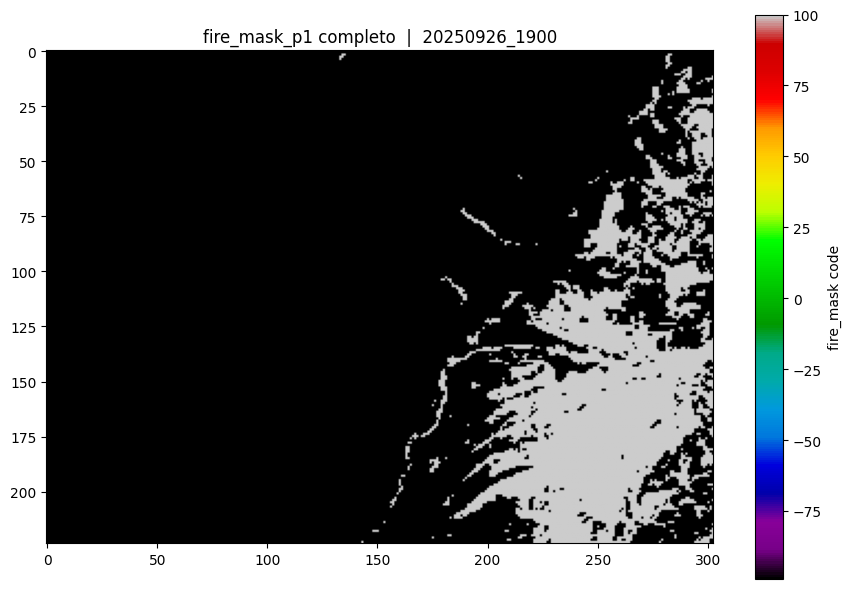


Nota: los píxeles candidatos (que pasan a Part II) tienen fire_mask == FireMask.INIT
  FireMask.INIT = -99


In [ ]:
# Visualización de la fire_mask de Part I
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(fire_mask_p1, cmap='nipy_spectral', origin='upper',
               vmin=fire_mask_p1.min(), vmax=fire_mask_p1.max())
plt.colorbar(im, ax=ax, label='fire_mask code')
ax.set_title(f'fire_mask_p1 completo  |  {TIMESTAMP}')
plt.tight_layout()
plt.show()

print('\nNota: los píxeles candidatos (que pasan a Part II) tienen fire_mask == FireMask.INIT')
print(f'  FireMask.INIT = {FireMask.INIT}')

---
## ¿Qué sigue?

La lista `candidates` y los arrays `fire_mask_p1`, `fail_char_p1` son la entrada de **Part II** (`run_part2`), que aplica:
- tests de confirmación / eliminación de falsas alarmas (`cond1`, `cond2`, `cond3`)
- upgrade de confianza (→ HIGH/MED/LOW)
- filtrado temporal (offset +20)

El notebook de Part II seguirá la misma estructura modular.